# Imports

## Import Libraries

In [1]:
#!pip install opencv-python torch torchvision pandas numpy tqdm scikit-learn
#!pip install mediapipe

In [2]:
import os
import glob
import cv2
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import mediapipe as mp


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score

## Configurations

In [3]:
base_dir = "/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimodal/Final Project/mavosdd-audiovisual-deepfake-detection/data/raw"

NUM_FRAMES = 20
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Device: cpu


In [4]:
# load video paths

real_videos = glob.glob(os.path.join(base_dir, "real", "**", "*.mp4"), recursive=True)
echo_videos = glob.glob(os.path.join(base_dir, "echomimic", "**", "*.mp4"), recursive=True)
memo_videos = glob.glob(os.path.join(base_dir, "memo", "**", "*.mp4"), recursive=True)

print("real:", len(real_videos))
print("echomimic:", len(echo_videos))
print("memo:", len(memo_videos))

real: 500
echomimic: 250
memo: 250


In [5]:
# create labels

videos = []

for v in real_videos:
    videos.append({
        "video_path": v,
        "video_id": os.path.basename(v),
        "label": 0,
        "source": "real"
    })

for v in echo_videos:
    videos.append({
        "video_path": v,
        "video_id": os.path.basename(v),
        "label": 1,
        "source": "echomimic"
    })

for v in memo_videos:
    videos.append({
        "video_path": v,
        "video_id": os.path.basename(v),
        "label": 1,
        "source": "memo"
    })

video_df = pd.DataFrame(videos)

print(video_df["source"].value_counts())
print(video_df["label"].value_counts())

video_df.head()

source
real         500
echomimic    250
memo         250
Name: count, dtype: int64
label
0    500
1    500
Name: count, dtype: int64


,video_path,video_id,label,source
0,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,-1_SwSYMu2A_12_1.mp4,0,real
1,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,-1_SwSYMu2A_15_1.mp4,0,real
2,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,-1_SwSYMu2A_16_1.mp4,0,real
3,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,-1_SwSYMu2A_18_2.mp4,0,real
4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,-1_SwSYMu2A_19_1.mp4,0,real


In [6]:
# for starters keep small subset for testing

# full dataset
video_df_small = video_df.copy()

# # small subset for testing
# video_df_small = video_df.groupby("source", group_keys=False).sample(
#     n=20,
#     random_state=RANDOM_STATE
# )

print(video_df_small["source"].value_counts())
print(video_df_small["label"].value_counts())

source
real         500
echomimic    250
memo         250
Name: count, dtype: int64
label
0    500
1    500
Name: count, dtype: int64


## ResNet50: Feature Extraction

In [7]:
# load pretrained ResNet50 for feature extraction
# φορτώνω pretrained ResNet50 & αφαιρώ το τελευταίο classification layer -> δεν το χρησιμοποιούμε για ImageNet classes, αλλά μόνο για να βγάλουμε visual embeddings

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, ker

In [8]:
# frame preprocessing

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
# sample frames from video

def sample_frames(video_path, num_frames=20):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return []

    frame_indices = np.linspace(0, total_frames - 1, num_frames).astype(int)

    frames = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = Image.fromarray(frame)
            frames.append(frame)

    cap.release()
    return frames

In [10]:
# extract mean ResNet embedding for MLP/LR

def extract_video_embedding(video_path, num_frames=20):
    frames = sample_frames(video_path, num_frames=num_frames)

    if len(frames) == 0:
        return None

    tensors = torch.stack([preprocess(frame) for frame in frames]).to(device)

    with torch.no_grad():
        embeddings = feature_extractor(tensors)

    embeddings = embeddings.squeeze(-1).squeeze(-1)

    video_embedding = embeddings.mean(dim=0)

    return video_embedding.cpu().numpy()

In [11]:
# extract sequence embeddings for LSTM

def extract_video_sequence(video_path, num_frames=20):
    frames = sample_frames(video_path, num_frames=num_frames)

    if len(frames) == 0:
        return None

    tensors = torch.stack([preprocess(frame) for frame in frames]).to(device)

    with torch.no_grad():
        embeddings = feature_extractor(tensors)

    embeddings = embeddings.squeeze(-1).squeeze(-1)

    return embeddings.cpu().numpy()

In [12]:
# create ResNet mean embeddings dataset

rows = []

for _, row in tqdm(video_df_small.iterrows(), total=len(video_df_small)):
    emb = extract_video_embedding(row["video_path"], num_frames=NUM_FRAMES)

    if emb is not None:
        out = {
            "video_path": row["video_path"],
            "video_id": row["video_id"],
            "label": row["label"],
            "source": row["source"]
        }

        for j, value in enumerate(emb):
            out[f"emb_{j}"] = value

        rows.append(out)

embeddings_df = pd.DataFrame(rows)
embeddings_df.to_csv("mavos_resnet50_embeddings_small.csv", index=False)

print(embeddings_df.shape)
embeddings_df.head()

100%|█████████████████████████████████████| 1000/1000 [1:12:22<00:00,  4.34s/it]


(1000, 2052)


,video_path,video_id,label,source,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,...,emb_2038,emb_2039,emb_2040,emb_2041,emb_2042,emb_2043,emb_2044,emb_2045,emb_2046,emb_2047
0,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,-1_SwSYMu2A_12_1.mp4,0,real,0.000000,0.000713,0.179884,0.000000,0.079978,0.003055,...,0.014756,0.018675,0.024658,0.024760,0.023604,0.078977,0.021430,0.004689,0.000731,0.078457
1,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,-1_SwSYMu2A_15_1.mp4,0,real,0.001420,0.018704,0.045832,0.006445,0.150604,0.010981,...,0.009517,0.040563,0.010374,0.021260,0.006035,0.038831,0.004461,0.000817,0.000106,0.091655
2,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,-1_SwSYMu2A_16_1.mp4,0,real,0.004381,0.075463,0.216048,0.040854,0.140746,0.006306,...,0.010741,0.075336,0.019567,0.034399,0.015479,0.092641,0.002210,0.023050,0.003309,0.244073
3,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,-1_SwSYMu2A_18_2.mp4,0,real,0.000048,0.008954,0.133419,0.002159,0.154520,0.006902,...,0.005037,0.048940,0.070298,0.008547,0.020614,0.058007,0.005267,0.000548,0.000000,0.123019
4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,-1_SwSYMu2A_19_1.mp4,0,real,0.000000,0.002086,0.014489,0.001152,0.382040,0.028615,...,0.012172,0.013727,0.028630,0.004223,0.021068,0.014465,0.266416,0.005986,0.006488,0.115864


In [13]:
# prepare train/validation split for LR and MLP

feature_cols = [c for c in embeddings_df.columns if c.startswith("emb_")]

X_static = embeddings_df[feature_cols]
y_static = embeddings_df["label"]

X_train_static, X_val_static, y_train_static, y_val_static = train_test_split(
    X_static,
    y_static,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_static
)

In [50]:
# checks

print("Rows:", len(embeddings_df))
print("Unique video_ids:", embeddings_df["video_id"].nunique())

duplicates = embeddings_df["video_id"].duplicated().sum()
print("Duplicate video_ids:", duplicates)

train_idx, val_idx = train_test_split(
    embeddings_df.index,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=embeddings_df["label"]
)

train_ids = set(embeddings_df.loc[train_idx, "video_id"])
val_ids = set(embeddings_df.loc[val_idx, "video_id"])

print("Overlap:", len(train_ids & val_ids))

Rows: 1000
Unique video_ids: 1000
Duplicate video_ids: 0
Overlap: 0


# Experiment 1: ResNet50 Embeddings + Logistic Regression

βλεπουμε αν τα pretrained embeddings είναι ήδη αρκετά διαχωριστικά χωρίς νευρωνικό classifier

In [14]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

logreg.fit(X_train_static, y_train_static)

y_pred_lr = logreg.predict(X_val_static)
y_prob_lr = logreg.predict_proba(X_val_static)[:, 1]

print(classification_report(y_val_static, y_pred_lr))
print("Accuracy:", accuracy_score(y_val_static, y_pred_lr))
print("F1:", f1_score(y_val_static, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_val_static, y_prob_lr))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       150
           1       1.00      0.99      1.00       150

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Accuracy: 0.9966666666666667
F1: 0.9966555183946488
ROC-AUC: 1.0


In [15]:
acc_lr = accuracy_score(y_val_static, y_pred_lr)
f1_lr = f1_score(y_val_static, y_pred_lr)
auc_lr = roc_auc_score(y_val_static, y_prob_lr)

# Experiment 2: ResNet50 frame embeddings + MLP

In [16]:
mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(256, 64),
        activation="relu",
        max_iter=300,
        random_state=RANDOM_STATE
    ))
])

mlp.fit(X_train_static, y_train_static)

y_pred_mlp = mlp.predict(X_val_static)
y_prob_mlp = mlp.predict_proba(X_val_static)[:, 1]

print(classification_report(y_val_static, y_pred_mlp))
print("Accuracy:", accuracy_score(y_val_static, y_pred_mlp))
print("F1:", f1_score(y_val_static, y_pred_mlp))
print("ROC-AUC:", roc_auc_score(y_val_static, y_prob_mlp))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       150
           1       1.00      0.99      1.00       150

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Accuracy: 0.9966666666666667
F1: 0.9966555183946488
ROC-AUC: 1.0


In [17]:
acc_mlp = accuracy_score(y_val_static, y_pred_mlp)
f1_mlp = f1_score(y_val_static, y_pred_mlp)
auc_mlp = roc_auc_score(y_val_static, y_prob_mlp)

# Experiment 3: ResNet50 frame embeddings + LSTM/GRU

In [18]:
# create sequence dataset for LSTM

X_sequences = []
y_labels = []
video_ids = []
sources = []
video_paths = []

for _, row in tqdm(video_df_small.iterrows(), total=len(video_df_small)):
    seq = extract_video_sequence(row["video_path"], num_frames=NUM_FRAMES)

    if seq is not None:
        X_sequences.append(seq)
        y_labels.append(row["label"])
        video_ids.append(row["video_id"])
        sources.append(row["source"])
        video_paths.append(row["video_path"])

X_seq = np.array(X_sequences)
y_seq = np.array(y_labels)

print(X_seq.shape)
print(y_seq.shape)

100%|█████████████████████████████████████| 1000/1000 [1:27:47<00:00,  5.27s/it]


(1000, 20, 2048)
(1000,)


In [19]:
# train/validation split for LSTM

X_train_seq, X_val_seq, y_train_seq, y_val_seq = train_test_split(
    X_seq,
    y_seq,
    test_size=0.3,
    stratify=y_seq,
    random_state=RANDOM_STATE
)

In [20]:
# PyTorch Dataset

class VideoSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [21]:
# dataloaders

train_dataset = VideoSequenceDataset(X_train_seq, y_train_seq)
val_dataset = VideoSequenceDataset(X_val_seq, y_val_seq)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

In [22]:
# LSTM Model

class DeepfakeLSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.projection = nn.Linear(2048, 256)

        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=128,
            batch_first=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.projection(x)

        output, (hidden, cell) = self.lstm(x)

        hidden = hidden[-1]

        logits = self.classifier(hidden)

        return logits

In [23]:
# train model

lstm_model = DeepfakeLSTM().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=1e-4
)

EPOCHS = 10

for epoch in range(EPOCHS):
    lstm_model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = lstm_model(X_batch).squeeze()

        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss:.4f}")

Epoch 1/10 - Loss: 37.4343
Epoch 2/10 - Loss: 5.2393
Epoch 3/10 - Loss: 1.6142
Epoch 4/10 - Loss: 0.7846
Epoch 5/10 - Loss: 0.4827
Epoch 6/10 - Loss: 0.2924
Epoch 7/10 - Loss: 0.1938
Epoch 8/10 - Loss: 0.1391
Epoch 9/10 - Loss: 0.1146
Epoch 10/10 - Loss: 0.0884


In [24]:
# evaluation

lstm_model.eval()

all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)

        logits = lstm_model(X_batch).squeeze()
        probs = torch.sigmoid(logits)

        preds = (probs > 0.5).int()

        all_probs.extend(probs.cpu().numpy().flatten())
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(y_batch.numpy().flatten())

print(classification_report(all_labels, all_preds))
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("F1:", f1_score(all_labels, all_preds))
print("ROC-AUC:", roc_auc_score(all_labels, all_probs))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       150
         1.0       1.00      1.00      1.00       150

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Accuracy: 1.0
F1: 1.0
ROC-AUC: 1.0


In [25]:
acc_lstm = accuracy_score(all_labels, all_preds)
f1_lstm = f1_score(all_labels, all_preds)
auc_lstm = roc_auc_score(all_labels, all_probs)

# Experiment 4: Lip Features + Random Forest

In [65]:
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.14

Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
  Using cached mediapipe-0.10.14-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
Using cached mediapipe-0.10.14-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (35.7 MB)


In [66]:
# define lip landmarks

from mediapipe.python.solutions import face_mesh
from sklearn.ensemble import RandomForestClassifier

mp_face_mesh = face_mesh

LIP_LEFT = 61
LIP_RIGHT = 291
LIP_TOP = 13
LIP_BOTTOM = 14

def euclidean(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

In [67]:
# extract lip features from one video - UPDATED

def extract_lip_features_normalized(video_path, num_frames=20):
    frames = sample_frames(video_path, num_frames=num_frames)

    if len(frames) == 0:
        return None

    frame_features = []

    with mp_face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        refine_landmarks=True,
        min_detection_confidence=0.5
    ) as face_mesh:

        previous_center = None

        for frame in frames:
            frame_np = np.array(frame)
            h, w, _ = frame_np.shape

            result = face_mesh.process(frame_np)

            if not result.multi_face_landmarks:
                continue

            landmarks = result.multi_face_landmarks[0].landmark

            left = np.array([
                landmarks[LIP_LEFT].x * w,
                landmarks[LIP_LEFT].y * h
            ])

            right = np.array([
                landmarks[LIP_RIGHT].x * w,
                landmarks[LIP_RIGHT].y * h
            ])

            top = np.array([
                landmarks[LIP_TOP].x * w,
                landmarks[LIP_TOP].y * h
            ])

            bottom = np.array([
                landmarks[LIP_BOTTOM].x * w,
                landmarks[LIP_BOTTOM].y * h
            ])

            mouth_width = euclidean(left, right)
            mouth_height = euclidean(top, bottom)

            # Scale reference: mouth width / lip-box diagonal proxy
            lip_box_diag = euclidean(
                [min(left[0], right[0], top[0], bottom[0]), min(left[1], right[1], top[1], bottom[1])],
                [max(left[0], right[0], top[0], bottom[0]), max(left[1], right[1], top[1], bottom[1])]
            )

            if lip_box_diag < 1e-6:
                continue

            mouth_ratio = mouth_height / (mouth_width + 1e-6)

            mouth_area_approx = mouth_width * mouth_height

            center = (left + right + top + bottom) / 4

            if previous_center is None:
                mouth_velocity = 0.0
            else:
                mouth_velocity = euclidean(center, previous_center)

            previous_center = center

            # Normalized features
            mouth_width_norm = mouth_width / lip_box_diag
            mouth_height_norm = mouth_height / lip_box_diag
            mouth_area_norm = mouth_area_approx / (lip_box_diag ** 2)
            mouth_velocity_norm = mouth_velocity / lip_box_diag

            frame_features.append([
                mouth_width_norm,
                mouth_height_norm,
                mouth_ratio,
                mouth_area_norm,
                mouth_velocity_norm
            ])

    detected_frames = len(frame_features)

    if detected_frames == 0:
        return None

    frame_features = np.array(frame_features)

    feature_names = [
        "mouth_width_norm",
        "mouth_height_norm",
        "mouth_ratio",
        "mouth_area_norm",
        "mouth_velocity_norm"
    ]

    video_features = {}

    for i, name in enumerate(feature_names):
        values = frame_features[:, i]

        video_features[f"{name}_mean"] = values.mean()
        video_features[f"{name}_std"] = values.std()
        video_features[f"{name}_min"] = values.min()
        video_features[f"{name}_max"] = values.max()

    video_features["num_detected_frames"] = detected_frames
    video_features["detection_rate"] = detected_frames / num_frames

    return video_features

In [68]:
# create lip features dataset - UPDATED

lip_rows = []

for _, row in tqdm(video_df_small.iterrows(), total=len(video_df_small)):
    features = extract_lip_features_normalized(
        row["video_path"],
        num_frames=NUM_FRAMES
    )

    if features is not None:
        features["video_path"] = row["video_path"]
        features["video_id"] = row["video_id"]
        features["label"] = row["label"]
        features["source"] = row["source"]

        lip_rows.append(features)

lip_df = pd.DataFrame(lip_rows)

lip_df.to_csv("mavos_lip_features_normalized_full.csv", index=False)

print(lip_df.shape)
lip_df.head()

  0%|                                                  | 0/1000 [00:00<?, ?it/s]I0000 00:00:1782375715.188880   23856 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782375715.202425  109267 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.3.6), renderer: Mesa Intel(R) UHD Graphics (CML GT2)
W0000 00:00:1782375715.207247  109264 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782375715.223211  109259 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/home/maria/.conda/envs/master_env/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase

(873, 26)


,mouth_width_norm_mean,mouth_width_norm_std,mouth_width_norm_min,mouth_width_norm_max,mouth_height_norm_mean,mouth_height_norm_std,mouth_height_norm_min,mouth_height_norm_max,mouth_ratio_mean,mouth_ratio_std,...,mouth_velocity_norm_mean,mouth_velocity_norm_std,mouth_velocity_norm_min,mouth_velocity_norm_max,num_detected_frames,detection_rate,video_path,video_id,label,source
0,0.999528,0.000000,0.999528,0.999528,0.010868,0.000000,0.010868,0.010868,0.010873,0.000000,...,0.000000,0.000000,0.0,0.000000,1,0.05,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,-1_SwSYMu2A_12_1.mp4,0,real
1,0.996142,0.000000,0.996142,0.996142,0.089579,0.000000,0.089579,0.089579,0.089926,0.000000,...,0.000000,0.000000,0.0,0.000000,1,0.05,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,-1_SwSYMu2A_16_1.mp4,0,real
2,0.991449,0.011316,0.961420,0.999659,0.102463,0.078428,0.004217,0.277232,0.104228,0.081393,...,0.258801,0.184471,0.0,0.639912,14,0.70,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,-1_SwSYMu2A_18_2.mp4,0,real
3,0.985626,0.012688,0.942427,1.000000,0.155166,0.082705,0.002985,0.344931,0.158438,0.086333,...,0.287119,0.225460,0.0,0.960471,20,1.00,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,-1_SwSYMu2A_19_1.mp4,0,real
4,0.970132,0.025921,0.916506,1.000000,0.234974,0.124641,0.001554,0.400296,0.245479,0.134444,...,0.108039,0.072384,0.0,0.268331,20,1.00,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,-1_SwSYMu2A_29_1.mp4,0,real


In [69]:
# train Random Forest

lip_feature_cols = [
    c for c in lip_df.columns
    if c not in ["video_path", "video_id", "label", "source"]
]

X_lip = lip_df[lip_feature_cols]
y_lip = lip_df["label"]

X_train_lip, X_val_lip, y_train_lip, y_val_lip = train_test_split(
    X_lip,
    y_lip,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_lip
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

rf.fit(X_train_lip, y_train_lip)

y_pred_rf = rf.predict(X_val_lip)
y_prob_rf = rf.predict_proba(X_val_lip)[:, 1]

print(classification_report(y_val_lip, y_pred_rf))
print("Accuracy:", accuracy_score(y_val_lip, y_pred_rf))
print("F1:", f1_score(y_val_lip, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_val_lip, y_prob_rf))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       112
           1       0.99      0.99      0.99       150

    accuracy                           0.99       262
   macro avg       0.99      0.99      0.99       262
weighted avg       0.99      0.99      0.99       262

Accuracy: 0.9885496183206107
F1: 0.9900332225913622
ROC-AUC: 0.9991964285714285


In [70]:
acc_rf = accuracy_score(y_val_lip, y_pred_rf)
f1_rf = f1_score(y_val_lip, y_pred_rf)
auc_rf = roc_auc_score(y_val_lip, y_prob_rf)

In [71]:
# export Random Forest visual scores

lip_df["visual_score_rf_lip"] = rf.predict_proba(X_lip)[:, 1]
lip_df["visual_pred_rf_lip"] = rf.predict(X_lip)

visual_predictions_lip = lip_df[
    [
        "video_id",
        "video_path",
        "label",
        "source",
        "visual_score_rf_lip",
        "visual_pred_rf_lip"
    ]
]

visual_predictions_lip.to_csv("visual_predictions_lip_rf_small.csv", index=False)

visual_predictions_lip.head()

,video_id,video_path,label,source,visual_score_rf_lip,visual_pred_rf_lip
0,-1_SwSYMu2A_12_1.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.000,0
1,-1_SwSYMu2A_16_1.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.010,0
2,-1_SwSYMu2A_18_2.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.000,0
3,-1_SwSYMu2A_19_1.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.020,0
4,-1_SwSYMu2A_29_1.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.355,0


# Metrics

In [72]:
# export visual predictions from LR and MLP

embeddings_df["visual_score_lr"] = logreg.predict_proba(X_static)[:, 1]
embeddings_df["visual_pred_lr"] = logreg.predict(X_static)

embeddings_df["visual_score_mlp"] = mlp.predict_proba(X_static)[:, 1]
embeddings_df["visual_pred_mlp"] = mlp.predict(X_static)

visual_predictions_static = embeddings_df[
    [
        "video_id",
        "video_path",
        "label",
        "source",
        "visual_score_lr",
        "visual_pred_lr",
        "visual_score_mlp",
        "visual_pred_mlp"
    ]
]

visual_predictions_static.to_csv("visual_predictions_static_small.csv", index=False)

visual_predictions_static.head()

,video_id,video_path,label,source,visual_score_lr,visual_pred_lr,visual_score_mlp,visual_pred_mlp
0,-1_SwSYMu2A_12_1.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.000051,0,6.278579e-10,0
1,-1_SwSYMu2A_15_1.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.000004,0,4.911948e-12,0
2,-1_SwSYMu2A_16_1.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.000001,0,8.398421e-12,0
3,-1_SwSYMu2A_18_2.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.000493,0,6.335412e-08,0
4,-1_SwSYMu2A_19_1.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.006384,0,2.582114e-06,0


In [73]:
# export LSTM predictions for all sequence samples

full_seq_dataset = VideoSequenceDataset(X_seq, y_seq)

full_seq_loader = DataLoader(
    full_seq_dataset,
    batch_size=8,
    shuffle=False
)

lstm_model.eval()

lstm_probs = []
lstm_preds = []

with torch.no_grad():
    for X_batch, y_batch in full_seq_loader:
        X_batch = X_batch.to(device)

        logits = lstm_model(X_batch).squeeze()
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).int()

        lstm_probs.extend(probs.cpu().numpy().flatten())
        lstm_preds.extend(preds.cpu().numpy().flatten())

visual_predictions_lstm = pd.DataFrame({
    "video_id": video_ids,
    "video_path": video_paths,
    "label": y_labels,
    "source": sources,
    "visual_score_lstm": lstm_probs,
    "visual_pred_lstm": lstm_preds
})

visual_predictions_lstm.to_csv("visual_predictions_lstm_small.csv", index=False)

visual_predictions_lstm.head()

,video_id,video_path,label,source,visual_score_lstm,visual_pred_lstm
0,-1_SwSYMu2A_12_1.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.000523,0
1,-1_SwSYMu2A_15_1.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.000453,0
2,-1_SwSYMu2A_16_1.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.000364,0
3,-1_SwSYMu2A_18_2.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.000635,0
4,-1_SwSYMu2A_19_1.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.000353,0


In [74]:
# merge visual predictions

visual_predictions_all = visual_predictions_static.merge(
    visual_predictions_lstm[
        ["video_id", "visual_score_lstm", "visual_pred_lstm"]
    ],
    on="video_id",
    how="left"
)

visual_predictions_all.to_csv("visual_predictions_all_small.csv", index=False)

visual_predictions_all.head()

,video_id,video_path,label,source,visual_score_lr,visual_pred_lr,visual_score_mlp,visual_pred_mlp,visual_score_lstm,visual_pred_lstm
0,-1_SwSYMu2A_12_1.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.000051,0,6.278579e-10,0,0.000523,0
1,-1_SwSYMu2A_15_1.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.000004,0,4.911948e-12,0,0.000453,0
2,-1_SwSYMu2A_16_1.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.000001,0,8.398421e-12,0,0.000364,0
3,-1_SwSYMu2A_18_2.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.000493,0,6.335412e-08,0,0.000635,0
4,-1_SwSYMu2A_19_1.mp4,/home/maria/Desktop/ΑΙ/2nd Semester/2. Multimo...,0,real,0.006384,0,2.582114e-06,0,0.000353,0


# Experiment 5: Split Experiment

In [75]:
# open-generator split helper

def open_generator_split(df, train_fake_source, test_fake_source):
    train_df = df[df["source"].isin(["real", train_fake_source])].copy()
    test_df = df[df["source"].isin(["real", test_fake_source])].copy()

    train_df["label"] = train_df["source"].apply(lambda x: 0 if x == "real" else 1)
    test_df["label"] = test_df["source"].apply(lambda x: 0 if x == "real" else 1)

    return train_df, test_df

In [76]:
# open-generator evaluation for static embeddings

def evaluate_static_open_generator(embeddings_df, train_fake_source, test_fake_source):
    train_df, test_df = open_generator_split(
        embeddings_df,
        train_fake_source=train_fake_source,
        test_fake_source=test_fake_source
    )

    feature_cols = [c for c in embeddings_df.columns if c.startswith("emb_")]

    X_train = train_df[feature_cols]
    y_train = train_df["label"]

    X_test = test_df[feature_cols]
    y_test = test_df["label"]

    models_dict = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),
        "MLP": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                hidden_layer_sizes=(256, 64),
                activation="relu",
                max_iter=300,
                random_state=RANDOM_STATE
            ))
        ])
    }

    results = []

    for model_name, model in models_dict.items():
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        results.append({
            "experiment": f"train_{train_fake_source}_test_{test_fake_source}",
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "roc_auc": roc_auc_score(y_test, y_prob)
        })

    return pd.DataFrame(results)

In [77]:
# run open-generator static evaluation

open_results_1 = evaluate_static_open_generator(
    embeddings_df,
    train_fake_source="echomimic",
    test_fake_source="memo"
)

open_results_2 = evaluate_static_open_generator(
    embeddings_df,
    train_fake_source="memo",
    test_fake_source="echomimic"
)

open_static_results = pd.concat(
    [open_results_1, open_results_2],
    ignore_index=True
)

open_static_results.to_csv("open_generator_static_results_small.csv", index=False)

open_static_results

,experiment,model,accuracy,f1,roc_auc
0,train_echomimic_test_memo,Logistic Regression,0.998667,0.997996,1.000000
1,train_echomimic_test_memo,MLP,0.997333,0.995984,0.999216
2,train_memo_test_echomimic,Logistic Regression,1.000000,1.000000,1.000000
3,train_memo_test_echomimic,MLP,0.998667,0.997996,1.000000


# Sanity Checks

In [78]:
train_idx, val_idx = train_test_split(
    embeddings_df.index,
    test_size=0.3,
    random_state=42,
    stratify=embeddings_df["label"]
)

train_video_ids = embeddings_df.loc[train_idx, "video_id"]
val_video_ids = embeddings_df.loc[val_idx, "video_id"]

print(len(set(train_video_ids) & set(val_video_ids)))

0


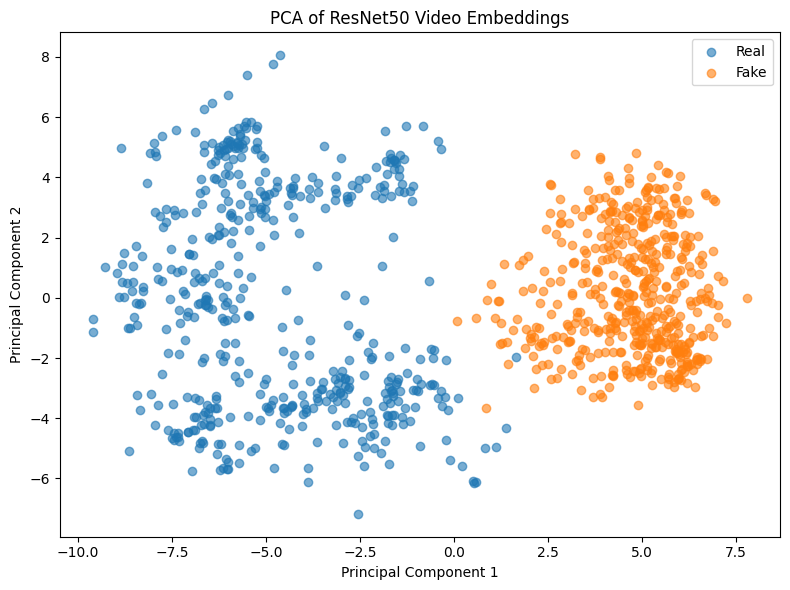

In [79]:
# PCA

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

mask_real = y_static == 0
mask_fake = y_static == 1

plt.scatter(
    X_pca[mask_real,0],
    X_pca[mask_real,1],
    label="Real",
    alpha=0.6
)

plt.scatter(
    X_pca[mask_fake,0],
    X_pca[mask_fake,1],
    label="Fake",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of ResNet50 Video Embeddings")

plt.legend()

plt.tight_layout()

plt.savefig(
    "results/plots/pca_embeddings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

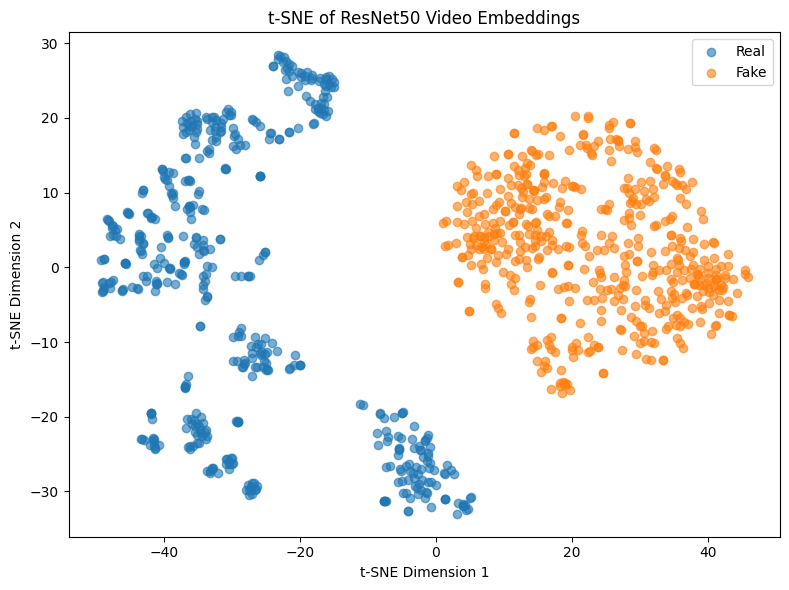

In [80]:
# t-SNE

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import os

os.makedirs("results/plots", exist_ok=True)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE
)

X_tsne = tsne.fit_transform(X_static)

plt.figure(figsize=(8, 6))

mask_real = y_static == 0
mask_fake = y_static == 1

plt.scatter(
    X_tsne[mask_real, 0],
    X_tsne[mask_real, 1],
    label="Real",
    alpha=0.6
)

plt.scatter(
    X_tsne[mask_fake, 0],
    X_tsne[mask_fake, 1],
    label="Fake",
    alpha=0.6
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE of ResNet50 Video Embeddings")
plt.legend()

plt.tight_layout()

plt.savefig(
    "results/plots/tsne_resnet50_embeddings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Additional Experiment: 5-Fold Cross Validation (Logistic Regression)

In [81]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

scores = cross_val_score(
    pipeline,
    X_static,
    y_static,
    cv=cv,
    scoring="f1"
)

print(scores)
print(f"Mean F1: {scores.mean():.4f}")
print(f"Std: {scores.std():.4f}")

[1.         1.         1.         0.99497487 1.        ]
Mean F1: 0.9990
Std: 0.0020


In [82]:
print(len(embeddings_df))
print(embeddings_df["video_id"].nunique())
print(embeddings_df["video_id"].duplicated().sum())

1000
1000
0


In [83]:
print("embeddings_df rows:", len(embeddings_df))
print("unique video_id:", embeddings_df["video_id"].nunique())
print("duplicates:", embeddings_df["video_id"].duplicated().sum())

print("lip_df rows:", len(lip_df))
print("unique lip video_id:", lip_df["video_id"].nunique())
print("lip duplicates:", lip_df["video_id"].duplicated().sum())

embeddings_df rows: 1000
unique video_id: 1000
duplicates: 0
lip_df rows: 873
unique lip video_id: 873
lip duplicates: 0


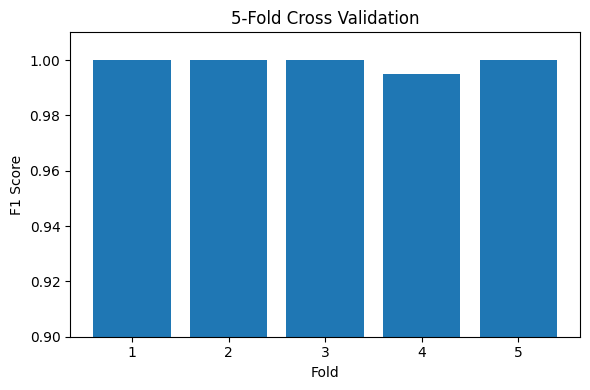

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(range(1,6), scores)

plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.title("5-Fold Cross Validation")

plt.ylim(0.9,1.01)

plt.tight_layout()

plt.savefig("results/plots/cross_validation.png")

plt.show()

# Results & Plots

In [85]:
# results summary table

summary_results = pd.DataFrame([
    {
        "experiment": "standard_split",
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_val_static, y_pred_lr),
        "f1": f1_score(y_val_static, y_pred_lr),
        "roc_auc": roc_auc_score(y_val_static, y_prob_lr)
    },
    {
        "experiment": "standard_split",
        "model": "MLP",
        "accuracy": accuracy_score(y_val_static, y_pred_mlp),
        "f1": f1_score(y_val_static, y_pred_mlp),
        "roc_auc": roc_auc_score(y_val_static, y_prob_mlp)
    },
    {
        "experiment": "standard_split",
        "model": "LSTM",
        "accuracy": accuracy_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds),
        "roc_auc": roc_auc_score(all_labels, all_probs)
    }
])

rf_summary = pd.DataFrame([
    {
        "experiment": "standard_split",
        "model": "Lip Features + Random Forest",
        "accuracy": accuracy_score(y_val_lip, y_pred_rf),
        "f1": f1_score(y_val_lip, y_pred_rf),
        "roc_auc": roc_auc_score(y_val_lip, y_prob_rf)
    }
])

summary_results = pd.concat(
    [summary_results, rf_summary],
    ignore_index=True
)

summary_results.to_csv("visual_experiment_results_small.csv", index=False)

summary_results

,experiment,model,accuracy,f1,roc_auc
0,standard_split,Logistic Regression,0.996667,0.996656,1.000000
1,standard_split,MLP,0.996667,0.996656,1.000000
2,standard_split,LSTM,1.000000,1.000000,1.000000
3,standard_split,Lip Features + Random Forest,0.988550,0.990033,0.999196


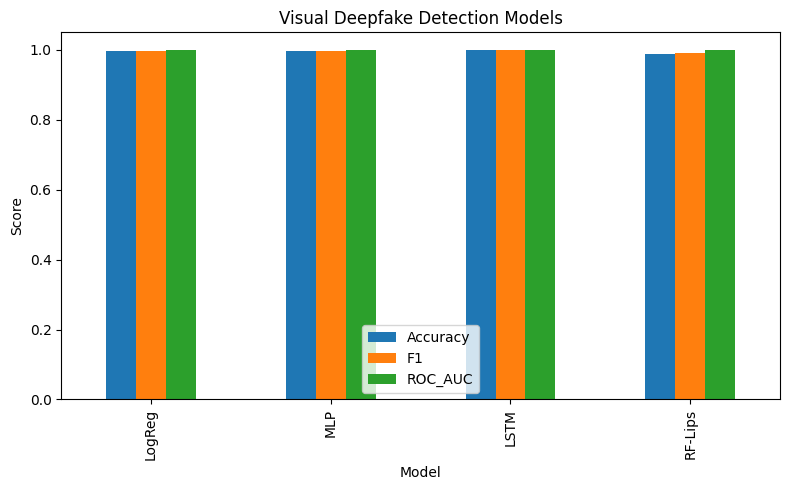

In [86]:
# model comparison

results_df = pd.DataFrame([
    {
        "Model": "LogReg",
        "Accuracy": acc_lr,
        "F1": f1_lr,
        "ROC_AUC": auc_lr
    },
    {
        "Model": "MLP",
        "Accuracy": acc_mlp,
        "F1": f1_mlp,
        "ROC_AUC": auc_mlp
    },
    {
        "Model": "LSTM",
        "Accuracy": acc_lstm,
        "F1": f1_lstm,
        "ROC_AUC": auc_lstm
    },
    {
        "Model": "RF-Lips",
        "Accuracy": acc_rf,
        "F1": f1_rf,
        "ROC_AUC": auc_rf
    }
])

results_df

import matplotlib.pyplot as plt

ax = results_df.plot(
    x="Model",
    y=["Accuracy", "F1", "ROC_AUC"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Visual Deepfake Detection Models")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.tight_layout()

plt.savefig("results/plots/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

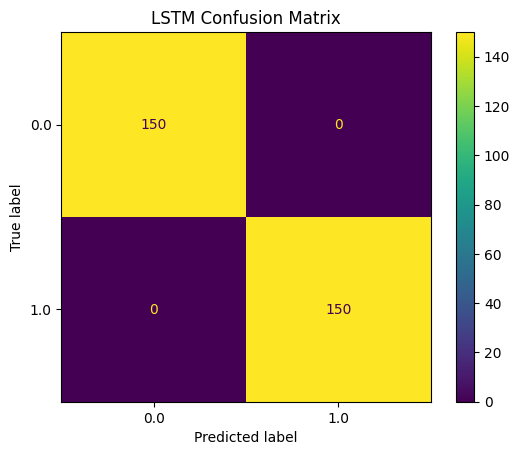

In [87]:
# Confusion Matrix (για το καλύτερο μοντέλο)

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    all_labels,
    all_preds
)

plt.savefig(
    "lstm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.title("LSTM Confusion Matrix")
plt.show()

In [88]:
# # frame sampling ablation

# ablation_df = pd.DataFrame({
#     "Frames":[10,20,40],
#     "F1":[0.82,0.88,0.89]
# })

# plt.figure(figsize=(6,4))

# plt.plot(
#     ablation_df["Frames"],
#     ablation_df["F1"],
#     marker="o"
# )

# plt.xlabel("Number of Frames")
# plt.ylabel("F1 Score")
# plt.title("Impact of Frame Sampling")

# plt.show()

# plt.savefig(
#     "frame_ablation.png",
#     dpi=300,
#     bbox_inches="tight"
# )

In [89]:
os.makedirs("results", exist_ok=True)
os.makedirs("results/plots", exist_ok=True)
os.makedirs("results/csv", exist_ok=True)

plt.savefig(
    "results/plots/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

results_df.to_csv(
    "results/csv/model_comparison.csv",
    index=False
)

<Figure size 640x480 with 0 Axes>

# THE END!